# Lending Club Loan Data Analysis

GitHub-friendly deep learning project notebook with detailed comments and execution workflow.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Input
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
df=pd.read_csv('loan_data.csv')
print(df.shape)
df.head()

(9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

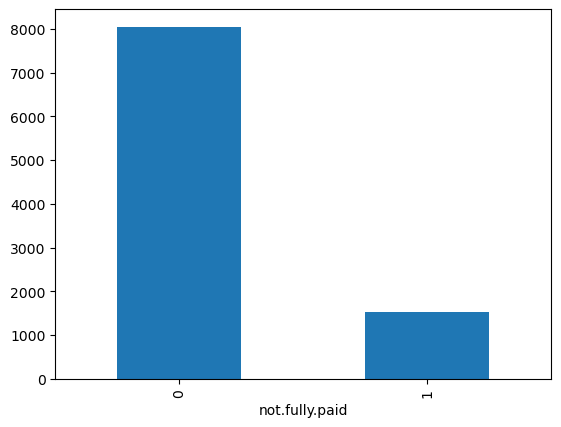

In [8]:
df['not.fully.paid'].value_counts().plot(kind='bar')
plt.show()

In [9]:
df=pd.get_dummies(df,drop_first=True)
corr=df.corr().abs()
upper=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))
drop=[c for c in upper.columns if any(upper[c]>0.95)]
df=df.drop(columns=drop)
X=df.drop('not.fully.paid',axis=1)
y=df['not.fully.paid']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [10]:
model=Sequential([
Input(shape=(X_train.shape[1],)),
Dense(128,activation='relu'),
Dropout(0.3),
Dense(64,activation='relu'),
Dropout(0.2),
Dense(32,activation='relu'),
Dense(1,activation='sigmoid')])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
es=EarlyStopping(patience=5,restore_best_weights=True)
model.fit(X_train,y_train,validation_split=0.2,epochs=30,batch_size=32,callbacks=[es])

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8354 - loss: 0.4469 - val_accuracy: 0.8461 - val_loss: 0.4059
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8393 - loss: 0.4198 - val_accuracy: 0.8467 - val_loss: 0.4018
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8381 - loss: 0.4189 - val_accuracy: 0.8467 - val_loss: 0.3978
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8386 - loss: 0.4165 - val_accuracy: 0.8474 - val_loss: 0.4000
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8391 - loss: 0.4125 - val_accuracy: 0.8467 - val_loss: 0.4019
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8380 - loss: 0.4115 - val_accuracy: 0.8467 - val_loss: 0.3977
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8388 - loss: 0.4118 - val_accuracy: 0.8461 - val_loss: 0.4007
Epoch 8/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8381 - loss: 0.4101 - val_accuracy: 0.

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[[1603    6]
 [ 302    5]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1609
           1       0.45      0.02      0.03       307

    accuracy                           0.84      1916
   macro avg       0.65      0.51      0.47      1916
weighted avg       0.78      0.84      0.77      1916

0.6862335842967996


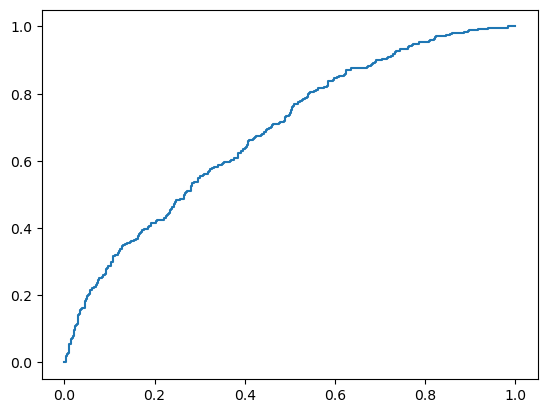

In [11]:
p=model.predict(X_test)
print(confusion_matrix(y_test,p>0.5))
print(classification_report(y_test,p>0.5))
print(roc_auc_score(y_test,p))
fpr,tpr,_=roc_curve(y_test,p)
plt.plot(fpr,tpr)
plt.show()